# Distribución muestral

## ¿Qué es una distribución muestral?
Es la distribución de un estadístico (por ejemplo, la media) calculado sobre muchas muestras distintas de la misma población.

## Idea importante
Si tomamos muchas muestras y calculamos su media, esas medias también forman una distribución.

## ¿Para qué sirve?
Nos ayuda a entender cuánto podría variar un resultado si repitiéramos el muestreo muchas veces.

## Relación con el Teorema del Límite Central
A medida que el tamaño de la muestra aumenta, la distribución de las medias tiende a parecerse a una distribución normal.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
penguins = sns.load_dataset("penguins").dropna()

medias = []

for _ in range(1000):
  muestra = penguins.sample(n=30,replace=False)
  medias.append(muestra["body_mass_g"].mean())

In [4]:
medias = pd.Series(medias)
medias.shape

(1000,)

# GRAFICAMOS LA DISTRIBUCIÓN MUESTRAL

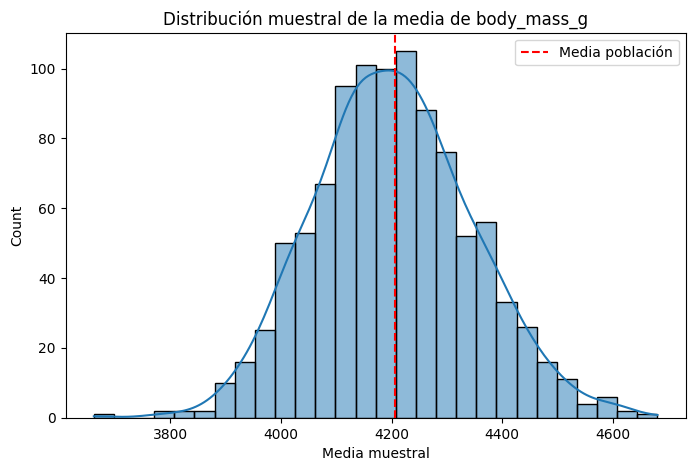

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.histplot(medias, kde=True)
plt.axvline(penguins["body_mass_g"].mean(), color="red", linestyle="--", label="Media población")
plt.title("Distribución muestral de la media de body_mass_g")
plt.xlabel("Media muestral")
plt.legend()
plt.show()

In [6]:
print("Media de las medias muestrales:", round(medias.mean(), 2))
print("Media de la población:", round(penguins["body_mass_g"].mean(), 2))

Media de las medias muestrales: 4203.16
Media de la población: 4207.06


# Error estándar

## ¿Qué es el error estándar?
El **error estándar** mide cuánto varía un estadístico de muestra a muestra.

## Diferencia con la desviación estándar
- **Desviación estándar**: variabilidad de los datos individuales.
- **Error estándar**: variabilidad de una métrica, como la media muestral.

## Fórmula del error estándar de la media
SE = s / raíz(n)

Donde:
- s = desviación estándar de la muestra
- n = tamaño de la muestra

## Interpretación
Si el error estándar es pequeño, la media muestral suele estar cerca de la media poblacional.

In [7]:
muestra = penguins.sample(n=50, random_state=42)
s = muestra["body_mass_g"].std()
n = len(muestra)
se = s / np.sqrt(n)

print("Desviación estándar muestral:", round(s, 2))
print("Tamaño de muestra:", n)
print("Error estándar:", round(se, 2))

Desviación estándar muestral: 770.6
Tamaño de muestra: 50
Error estándar: 108.98


# Aproximar el error estándar usando simulación

In [8]:
medias = []

for _ in range(1000):
    muestra_temp = penguins.sample(n=50, replace=False)
    medias.append(muestra_temp["body_mass_g"].mean())

error_estandar_simulado = np.std(medias, ddof=1)

print("Error estándar por fórmula:", round(se, 2))
print("Error estándar por simulación:", round(error_estandar_simulado, 2))

Error estándar por fórmula: 108.98
Error estándar por simulación: 101.61
